In [ ]:
import cv2, torch, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from gaze_av_aloha.policies.gaze_policy.gaze_model import GazeModel
from torchvision.transforms import Resize, Normalize

# ========= 你的原始配置 =========
input_shape = (240, 320)
resize_shape = (120, 160)
model_repo_id = "Jinyu220/gaze_model_av_aloha_real_NEW1_toothbrush"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GazeModel(resize_shape=resize_shape).to(device)
model = model.from_pretrained(model_repo_id).to(device)
model.eval()

resize = Resize(input_shape)
normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# =================================

def draw_cross(img, center, size=10, color=(255, 0, 0), thickness=2):
    """在 BGR 图像上画十字；color 默认为红色(BGR)"""
    x, y = center
    cv2.line(img, (x, y - size), (x, y + size), color, thickness)
    cv2.line(img, (x - size, y), (x + size, y), color, thickness)
    return img

def load_image_rgb_tensor(img_path: str) -> torch.Tensor:
    """
    读取单张图片 → torch.float32张量 [1,3,H,W], 值域0~1，RGB顺序
    """
    bgr = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(rgb).float() / 255.0        # [H,W,3] 0~1
    t = t.permute(2, 0, 1).unsqueeze(0).contiguous() # [1,3,H,W]
    return t

@torch.no_grad()
def run_single_image(img_path: str,
                     output_path: str = "overlay_result.png",
                     cross_size: int = 5,
                     blend_alpha: float = 0.5):
    """
    读取一张图片，送入模型，输出叠加热力图 + 预测十字的可视化 PNG
    """
    # 1) 读图到 tensor（RGB, 0~1）
    img_tensor = load_image_rgb_tensor(img_path).to(device)        # [1,3,H,W]

    # 2) 保留一份原始可视化用图（RGB, uint8）
    img_vis = (img_tensor[0].clamp(0, 1) * 255).byte().cpu().permute(1, 2, 0).numpy()  # [H,W,3]

    # 3) 预处理：按你原代码的流程 resize -> normalize
    img_in = resize(img_tensor)          # [1,3,h,w] 到 input_shape
    img_in = normalize(img_in)

    # 4) 前向：假设返回 (pred, heatmaps)
    pred, heatmaps = model(img_in)       # pred: [1,2] (归一化到[-1,1])；heatmaps: [1,H,W] 或 [1,1,H,W] 或 [1,C,H,W]

    # 5) 取第0张热力图为可视化
    hmap = heatmaps[0]
    if torch.is_tensor(hmap):
        hmap = hmap.detach().cpu()
    if hmap.ndim == 3:      # [C,H,W] -> 取第0通道（按你原逻辑）
        hmap = hmap[0]
    hmap = hmap.numpy()     # [H,W]

    # 6) 归一化热力图（防常量）并上色 (plasma)
    ptp = np.ptp(hmap)
    if ptp < 1e-8:
        hmap_norm = np.zeros_like(hmap, dtype=np.float32)
    else:
        hmap_norm = (hmap - hmap.min()) / ptp

    hmap_color = plt.cm.plasma(hmap_norm)[..., :3]   # [H,W,3], 0~1, RGB
    hmap_color = (hmap_color * 255).astype(np.uint8)

    # 7) 将原图缩放到热力图分辨率以对齐叠加
    img_resized = cv2.resize(img_vis, (hmap_color.shape[1], hmap_color.shape[0]), interpolation=cv2.INTER_NEAREST)

    # 8) 叠加（OpenCV 需要 BGR）
    overlay_rgb = cv2.addWeighted(img_resized, 1.0 - blend_alpha, hmap_color, blend_alpha, 0.0)
    overlay_bgr = cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR)

    # 9) 将 pred 的 [-1,1] 坐标映射到像素坐标（与你原逻辑一致）
    p = pred[0].detach().cpu().numpy()   # [2]
    px = float(((p[0] + 1.0) / 2.0) * hmap_color.shape[1])
    py = float(((p[1] + 1.0) / 2.0) * hmap_color.shape[0])

    # 10) 画十字（红色）
    overlay_bgr = draw_cross(overlay_bgr, center=(int(round(px)), int(round(py))), size=cross_size, color=(255, 0, 0), thickness=2)

    # 11) 保存
    Path(output_path).parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(output_path, overlay_bgr)
    print(f"[OK] Saved overlay to: {output_path}")

# ===== 使用示例 =====
# 指定输入图片和输出路径
IMG_PATH = "image.png"     # <- 改成你的图片路径
OUTPUT_PATH = "result.png"
run_single_image(IMG_PATH, OUTPUT_PATH)

TypeError: Size should be int or sequence. Got <class 'torch.Tensor'>

In [ ]:
# input_shape = (240, 320)
# resize_shape=(120, 160)
# task = "thread_needle"
# dataset = f"iantc104/av_aloha_sim_{task}"
# model_repo_id = f"iantc104/gaze_model_av_aloha_sim_{task}"
# image_keys = [
#     "observation.images.zed_cam_left",
# ]
# eye_keys = [
#     "left_eye",
# ]

input_shape = (240, 320)
resize_shape=(120, 160)
dataset = f"Jinyu220/shoot"
model_repo_id = f"Jinyu220/gaze_model_av_aloha_real_NEW1_toothbrush"
image_keys = [
    "observation.images.left_eye_cam",
]
eye_keys = [
    "left_eye",
]

In [3]:

from gym_av_aloha.datasets.av_aloha_dataset import transform_image


delta_timestamps = {
    k: [0] for k in image_keys + eye_keys
}
dataset = AVAlohaDataset(
    repo_id=dataset,
    delta_timestamps=delta_timestamps,
    #image_transforms=transform_image,
)

dataloader = DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
)


avalohadataset: /home/jinyu/GitHub/gaze-av-aloha/gym_av_aloha/outputs/Jinyu220/toothbrush


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GazeModel(
    resize_shape=resize_shape,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
resize = Resize(input_shape)
normalize = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

In [5]:
model = model.from_pretrained(model_repo_id).to(device)

config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/57.5M [00:00<?, ?B/s]

In [ ]:
def draw_cross(img, center, size=10, color=(0, 0, 255), thickness=2):
    """
    Draws a cross (target-like +) on the image.

    Parameters:
    - img: Input image (numpy array)
    - center: (x, y) coordinates of the cross center
    - size: Length from center to end of each line
    - color: BGR color tuple (default: red)
    - thickness: Line thickness
    """
    x, y = center
    # Vertical line
    cv2.line(img, (x, y - size), (x, y + size), color, thickness)
    # Horizontal line
    cv2.line(img, (x - size, y), (x + size, y), color, thickness)

    return img

ranges = [
    [1217,1582]
]
eval_dataset = Subset(dataset, sum([list(range(start, end)) for start, end in ranges], []))
eval_dataloader = DataLoader(eval_dataset, batch_size=64, shuffle=False)
img = None 
heatmap = None
model.eval()
video = []
with torch.no_grad():
    for batch in tqdm(eval_dataloader, desc="Evaluation"):
        images = batch[image_keys[0]].to(device).squeeze(1)
        eye = batch[eye_keys[0]].to(device).squeeze(1)
        images = resize(images)
        pred, heatmaps = model(normalize(images))

        # Visualize a few examples
        for i in range(images.size(0)):
            img = images[i].cpu()
            img = (img * 255).byte().permute(1, 2, 0).numpy()
            heatmap = heatmaps[i].cpu()

            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
            heatmap = plt.cm.plasma(heatmap.numpy())  # Apply colormap
            heatmap = (heatmap[:, :, :3] * 255).astype(np.uint8)

            img = cv2.resize(img, (heatmap.shape[1], heatmap.shape[0]), interpolation=cv2.INTER_NEAREST)
            overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)
            # overlay = cv2.circle(overlay, (int(px), int(py)), 3, (0, 255, 0), -1)
            # pred[i][0] = ((pred[i][0] / 640) * 2) -1
            # pred[i][1] = ((pred[i][1] / 480) * 2) -1
            predx = ((pred[i][0] + 1) / 2) * heatmap.shape[1]
            predy = ((pred[i][1] + 1) / 2) * heatmap.shape[0]

            # overlay = cv2.circle(overlay, (int(predx), int(predy)), 3, (255, 255, 0), -1)
            overlay = draw_cross(overlay, center=(int(predx), int(predy)), size=5, color=(255, 0, 0), thickness=2)

            video.append(overlay)

# Save video
video_path = "mdn_saliency_vide_augmentation.mp4"
imageio.mimwrite(video_path, video, fps=25)

# Display video in Jupyter
display(Video(video_path, embed=True, width=512, height=384))


Evaluation:   0%|          | 0/7 [00:00<?, ?it/s]

Evaluation: 100%|██████████| 7/7 [00:00<00:00, 14.29it/s]


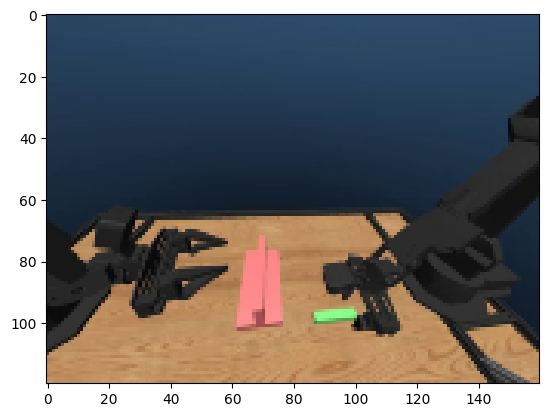

In [ ]:
plt.imsave("heatmap.png", overlay)
plt.imshow()
